# Desafio Digital Grid — Ricardo M. D. C. Junior

Solução das questões Q0 a Q5. O resumo do que fiz (e do que deixei de fora) está no
`SOLUCAO.md`. Mês de referência: **2026-07-01**.

In [1]:
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 4)

---
## Q0 — Contrato de dados

Explorei as duas bases antes de escrever a função. O que encontrei:

**Consumo (5.074 linhas):**
- A mesma UC aparece com o ID formatado (`11.140.345.018-70`) e também só com
  dígitos (`1114034501870`). Conferi: os meses não se sobrepõem, ou seja, é a mesma
  série partida em duas. Sem juntar, a UC contaria duas vezes no rateio.
- 10 UCs têm sufixo `-CANCEL` no ID. Todas estão com consumo zero há meses e várias
  com saldo alto parado. O status virou uma coluna `cancelada` (vou precisar disso na Q4).
- 7 pares de linhas 100% duplicadas e mais 7 pares com a mesma UC/mês e valores um
  pouco diferentes (ex.: 24.141 vs 24.128) — parece refaturamento. Como não tem coluna
  de versão pra saber qual vale, fiquei com a média (a diferença é <1%).
- 4 consumos negativos (estorno?) e 7 valores absurdos tipo 15.070 kWh numa UC cuja
  mediana é 1.622 e o segundo maior valor é 2.415 — quase certeza de dígito extra
  (1.507 → 15.070). Usei a regra: valor > 8× a mediana da própria UC.

**Usina (49 linhas):** uma linha sem data, jul/2022 com 1 kWh (comissionamento) e um
colapso de geração em mar–jun/2024 (~24 mil vs ~300–400 mil nos vizinhos).

Decisão importante: o enunciado da Q1 diz que o rateio usa o consumo faturado **como
está**. Então negativos e outliers ficam na coluna `consumo_kwh` e a correção vai
para uma coluna separada, `consumo_modelagem` (NaN onde o valor é suspeito), que é a
que uso na Q3. A anomalia da usina fica só sinalizada (`flag_anomalia`) — a decisão
de usar ou não é da modelagem.

In [2]:
CAMINHO_CONSUMO = "consumer_unit_data.xlsx"
CAMINHO_USINA = "power_plant_data.xlsx"


def carregar_e_limpar(caminho_consumo=CAMINHO_CONSUMO, caminho_usina=CAMINHO_USINA):
    """Lê e limpa as duas bases. Devolve (consumo, usina, relatorio_de_qualidade).

    Função pura dos arquivos de entrada -> idempotente por construção.
    Garante 1 linha por UC/mês na base de consumo.
    """
    log = []

    def registrar(base, etapa, n, acao, motivo):
        log.append({"base": base, "etapa": etapa, "registros": int(n),
                    "acao": acao, "motivo": motivo})

    # ----- consumo -----
    cu = pd.read_excel(caminho_consumo)
    cu.columns = ["mes", "uc_original", "consumo_kwh", "saldo_kwh"]
    registrar("consumo", "leitura", len(cu), "entrada", "registros lidos do Excel")

    # normaliza o ID: tira -CANCEL, casa IDs sem máscara com a forma formatada
    uc = cu["uc_original"].str.strip()
    cancelada = uc.str.endswith("-CANCEL")
    uc = uc.str.replace("-CANCEL", "", regex=False)
    digitos = uc.str.replace(r"\D", "", regex=True)
    formatadas = uc[uc.str.contains(".", regex=False)]
    mapa = dict(zip(formatadas.str.replace(r"\D", "", regex=True), formatadas))
    cu["uc"] = digitos.map(lambda d: mapa.get(d, d))
    registrar("consumo", "normalizacao de ID", (cu["uc"] != uc).sum(), "corrigido",
              "IDs sem máscara unificados com o gêmeo formatado (mesmos dígitos = mesma UC)")

    ucs_canceladas = set(cu.loc[cancelada, "uc"])
    cu["cancelada"] = cu["uc"].isin(ucs_canceladas)
    registrar("consumo", "flag -CANCEL", cancelada.sum(), "corrigido",
              f"sufixo removido do ID e virou coluna booleana ({len(ucs_canceladas)} UCs)")

    antes = len(cu)
    cu = cu.drop_duplicates(subset=["mes", "uc", "consumo_kwh", "saldo_kwh"])
    registrar("consumo", "duplicata exata", antes - len(cu), "descartado",
              "mesma UC/mês/valores")

    n_conf = cu.duplicated(subset=["mes", "uc"], keep=False).sum()
    cu = (cu.groupby(["mes", "uc", "cancelada"], as_index=False)
            .agg(consumo_kwh=("consumo_kwh", "mean"), saldo_kwh=("saldo_kwh", "mean")))
    cu["consumo_kwh"] = cu["consumo_kwh"].round().astype(int)
    cu["saldo_kwh"] = cu["saldo_kwh"].round().astype(int)
    registrar("consumo", "duplicata conflitante", n_conf, "média",
              "mesma UC/mês, valores <1% diferentes; sem versão da fatura, média")

    cu["consumo_modelagem"] = cu["consumo_kwh"].astype(float)
    neg = cu["consumo_kwh"] < 0
    cu.loc[neg, "consumo_modelagem"] = np.nan
    registrar("consumo", "consumo negativo", neg.sum(), "NaN p/ modelagem",
              "faturado fica como está (regra da Q1); p/ modelo não é consumo físico")

    mediana_uc = cu.groupby("uc")["consumo_kwh"].transform("median")
    outlier = (cu["consumo_kwh"] > 8 * mediana_uc) & (mediana_uc > 100)
    cu.loc[outlier, "consumo_modelagem"] = np.nan
    registrar("consumo", "outlier de digitação", outlier.sum(), "NaN p/ modelagem",
              "> 8x a mediana da própria UC (todos ~10x o 2º maior valor)")

    cu = cu.sort_values(["uc", "mes"]).reset_index(drop=True)

    # ----- usina -----
    pp = pd.read_excel(caminho_usina)
    pp.columns = ["mes", "usina", "geracao_kwh"]
    registrar("usina", "leitura", len(pp), "entrada", "registros lidos do Excel")

    sem_data = pp["mes"].isna()
    pp = pp[~sem_data]
    registrar("usina", "sem data", sem_data.sum(), "descartado", "linha NaT com geração 0")

    espuria = pp["geracao_kwh"] <= 1
    pp = pp[~espuria]
    registrar("usina", "comissionamento", espuria.sum(), "descartado",
              "jul/2022 com 1 kWh não é operação")

    pp["flag_anomalia"] = pp["mes"].between("2024-03-01", "2024-06-01")
    registrar("usina", "colapso mar-jun/24", pp["flag_anomalia"].sum(), "sinalizado",
              "queda de ~93% por 4 meses; mantido, decisão fica p/ Q3b")

    pp = pp.sort_values("mes").reset_index(drop=True)
    return cu, pp, pd.DataFrame(log)


consumo, usina, relatorio = carregar_e_limpar()
relatorio

,base,etapa,registros,acao,motivo
0,consumo,leitura,5074,entrada,registros lidos do Excel
1,consumo,normalizacao de ID,107,corrigido,IDs sem máscara unificados com o gêmeo formata...
2,consumo,flag -CANCEL,356,corrigido,sufixo removido do ID e virou coluna booleana ...
3,consumo,duplicata exata,7,descartado,mesma UC/mês/valores
4,consumo,duplicata conflitante,14,média,"mesma UC/mês, valores <1% diferentes; sem vers..."
5,consumo,consumo negativo,4,NaN p/ modelagem,faturado fica como está (regra da Q1); p/ mode...
6,consumo,outlier de digitação,7,NaN p/ modelagem,> 8x a mediana da própria UC (todos ~10x o 2º ...
7,usina,leitura,49,entrada,registros lidos do Excel
8,usina,sem data,1,descartado,linha NaT com geração 0
9,usina,comissionamento,1,descartado,jul/2022 com 1 kWh não é operação


In [3]:
# idempotência (rodar 2x = mesmo resultado) e estrutura (1 linha por UC/mês)
c2, u2, r2 = carregar_e_limpar()
assert consumo.equals(c2) and usina.equals(u2) and relatorio.equals(r2)
assert not consumo.duplicated(subset=["mes", "uc"]).any()

print(f"consumo: {len(consumo)} linhas, {consumo['uc'].nunique()} UCs "
      f"({consumo.loc[consumo['cancelada'], 'uc'].nunique()} canceladas), "
      f"{consumo['mes'].min():%Y-%m} a {consumo['mes'].max():%Y-%m}")
print(f"usina: {len(usina)} meses, {usina['mes'].min():%Y-%m} a {usina['mes'].max():%Y-%m}")

consumo: 5060 linhas, 196 UCs (10 canceladas), 2023-07 a 2026-06
usina: 47 meses, 2022-08 a 2026-06


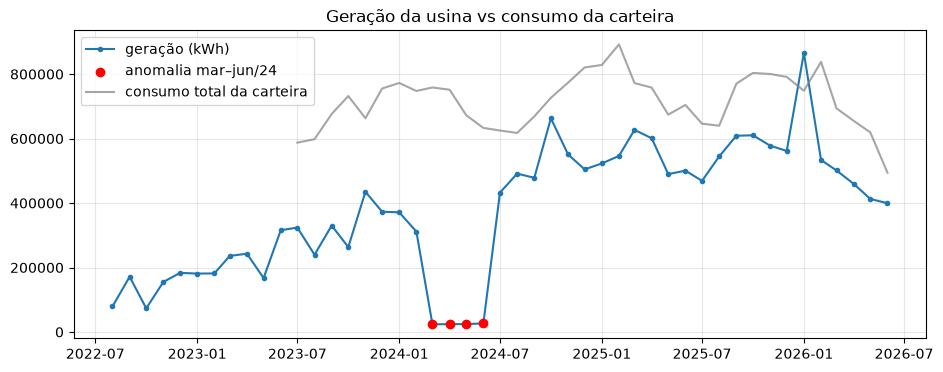

In [4]:
fig, ax = plt.subplots()
ax.plot(usina["mes"], usina["geracao_kwh"], marker="o", ms=3, label="geração (kWh)")
anom = usina[usina["flag_anomalia"]]
ax.scatter(anom["mes"], anom["geracao_kwh"], color="red", zorder=5, label="anomalia mar–jun/24")
tot = consumo.groupby("mes")["consumo_kwh"].sum()
ax.plot(tot.index, tot.values, color="gray", alpha=0.7, label="consumo total da carteira")
ax.set_title("Geração da usina vs consumo da carteira")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

O gráfico já entrega três coisas que vão importar adiante: o degrau de capacidade da
usina em jul/2024, o colapso de mar–jun/2024, e a geração de 2026 **caindo mês a mês**
enquanto o consumo da carteira segue estável.

---
## Q1 — Cobertura e rateio

A base de consumo termina em jun/2026, então o rateio de julho é calculado com a
última fatura conhecida — como acontece na operação real: `Ec` e `Cr` de **jun/2026**
definem o percentual que vale para julho.

Uso o consumo **faturado** (`consumo_kwh`), como o enunciado pede. A estrutura já
está garantida pela Q0 — sem o dedup, as UCs duplicadas levariam crédito em dobro.

In [5]:
OPF = 1.0  # quota de perfil
D = 0.0    # custo de disponibilidade


def calcular_rateio(cu, mes_base, opf=OPF, d=D):
    """ECA, cobertura (Co) e percentual de rateio (P) das UCs de um mês."""
    m = cu.loc[cu["mes"] == mes_base, ["uc", "cancelada", "consumo_kwh", "saldo_kwh"]].copy()
    m = m.rename(columns={"saldo_kwh": "cr"})
    m["eca"] = m["consumo_kwh"] * opf
    m["co"] = np.maximum(m["eca"] - (m["cr"] + d), 0.0)
    soma_co = m["co"].sum()
    m["p"] = m["co"] / soma_co if soma_co > 0 else 0.0
    return m.sort_values("p", ascending=False).reset_index(drop=True)


MES_BASE = pd.Timestamp("2026-06-01")
rateio = calcular_rateio(consumo, MES_BASE)
rateio.head(10)

,uc,cancelada,consumo_kwh,cr,eca,co,p
0,7.722.106.018-75,False,202385,0,202385.0,202385.0,0.414457
1,4.604.378.018-34,False,50384,0,50384.0,50384.0,0.103180
2,7.014.487.018-97,False,25520,0,25520.0,25520.0,0.052261
3,9.819.683.018-20,False,21163,0,21163.0,21163.0,0.043339
4,7.017.271.018-00,False,18795,0,18795.0,18795.0,0.038490
5,11.743.560.018-90,False,17685,0,17685.0,17685.0,0.036216
6,12.283.478.018-59,False,16934,0,16934.0,16934.0,0.034679
7,11.119.402.018-53,False,14308,0,14308.0,14308.0,0.029301
8,9.700.131.018-02,False,10715,0,10715.0,10715.0,0.021943
9,10.939.198.018-54,False,10018,0,10018.0,10018.0,0.020515


In [6]:
print(f"Σ P = {rateio['p'].sum():.10f}")
assert abs(rateio["p"].sum() - 1) < 1e-9
print(f"{len(rateio)} UCs no mês, {(rateio['co'] > 0).sum()} com Co > 0, "
      f"Σ Co = {rateio['co'].sum():,.0f} kWh")

Σ P = 1.0000000000
196 UCs no mês, 158 com Co > 0, Σ Co = 488,314 kWh


**Σ P = 1 prova que o rateio está certo?** Não. É só uma normalização — qualquer
vetor de Co não-negativo passa no teste, inclusive um calculado sobre dados errados.
Na base **bruta**, com UCs duplicadas no mês, a soma também daria exatamente 1, com a
UC duplicada levando o dobro. O que protege o rateio de verdade é a validação
estrutural (1 linha por UC/mês, feita na Q0). Σ P = 1 é condição necessária, não
suficiente.

**E se Σ Co = 0?** `P = Co/0` → divisão por zero; em float, `0/0` dá `NaN` e isso se
propaga pro faturamento. Em produção:
1. guarda de divisão (como na função acima): se ninguém precisa de crédito, o correto
   de negócio é P = 0 para todas, não um rateio arbitrário;
2. a energia do mês vira crédito na própria usina (ou numa UC âncora definida em
   contrato), regra explícita em configuração;
3. alerta: Σ Co = 0 com a usina gerando é sintoma de carteira com crédito sobrando —
   gatilho para rebalancear (Q4) ou captar novas UCs.

---
## Q2 — SQL

Dados limpos no DuckDB, uma única query, com o `NULLIF` fazendo o papel da guarda de
divisão por zero.

In [7]:
con = duckdb.connect()
con.register("consumo_limpo", consumo)

query = """
SELECT
    uc,
    consumo_kwh * 1.0                                AS eca,  -- ECA = Ec x OpF, OpF = 1
    saldo_kwh * 1.0                                  AS cr,
    GREATEST(consumo_kwh * 1.0 - (saldo_kwh + 0), 0) AS co,   -- D = 0
    COALESCE(
        GREATEST(consumo_kwh * 1.0 - (saldo_kwh + 0), 0)
        / NULLIF(SUM(GREATEST(consumo_kwh * 1.0 - (saldo_kwh + 0), 0)) OVER (), 0),
        0)                                           AS p
FROM consumo_limpo
WHERE mes = DATE '2026-06-01'
ORDER BY p DESC, uc
"""
rateio_sql = con.execute(query).df()
rateio_sql.head(10)

,uc,eca,cr,co,p
0,7.722.106.018-75,202385.0,0.0,202385.0,0.414457
1,4.604.378.018-34,50384.0,0.0,50384.0,0.103180
2,7.014.487.018-97,25520.0,0.0,25520.0,0.052261
3,9.819.683.018-20,21163.0,0.0,21163.0,0.043339
4,7.017.271.018-00,18795.0,0.0,18795.0,0.038490
5,11.743.560.018-90,17685.0,0.0,17685.0,0.036216
6,12.283.478.018-59,16934.0,0.0,16934.0,0.034679
7,11.119.402.018-53,14308.0,0.0,14308.0,0.029301
8,9.700.131.018-02,10715.0,0.0,10715.0,0.021943
9,10.939.198.018-54,10018.0,0.0,10018.0,0.020515


In [8]:
cmp = rateio_sql.merge(rateio, on="uc", suffixes=("_sql", "_py"))
assert len(cmp) == len(rateio) == len(rateio_sql)
for c in ["eca", "cr", "co", "p"]:
    assert np.allclose(cmp[f"{c}_sql"], cmp[f"{c}_py"]), c
print(f"ok — {len(cmp)} UCs, resultado idêntico ao da Q1")

ok — 196 UCs, resultado idêntico ao da Q1


---
## Q3 — Previsão

Regras: treino até 2026-05, validação em 2026-06, depois retreino com junho para
prever julho. Métricas: MAPE e MAE — e já adianto que o MAPE **quebra** nestes dados
(tem UC com consumo real = 0 no mês de validação → divisão por zero). Reporto também
o **WAPE** (Σ|erro| / Σ|real|), que é a alternativa que eu usaria em produção.

### (a) Consumo das Top 10 UCs

Duas das 12 maiores UCs do histórico estão canceladas (consumo 0 há mais de um ano) —
prever consumo delas não faz sentido, então o top 10 é entre as **ativas**.

In [9]:
ativas = consumo[~consumo["cancelada"]]
top10 = ativas.groupby("uc")["consumo_kwh"].sum().nlargest(10).index.tolist()
top10

['7.722.106.018-75',
 '12.303.171.018-06',
 '4.604.378.018-34',
 '7.025.224.018-01',
 '9.819.683.018-20',
 '7.014.487.018-97',
 '7.017.271.018-00',
 '11.743.560.018-90',
 '12.283.478.018-59',
 '11.119.402.018-53']

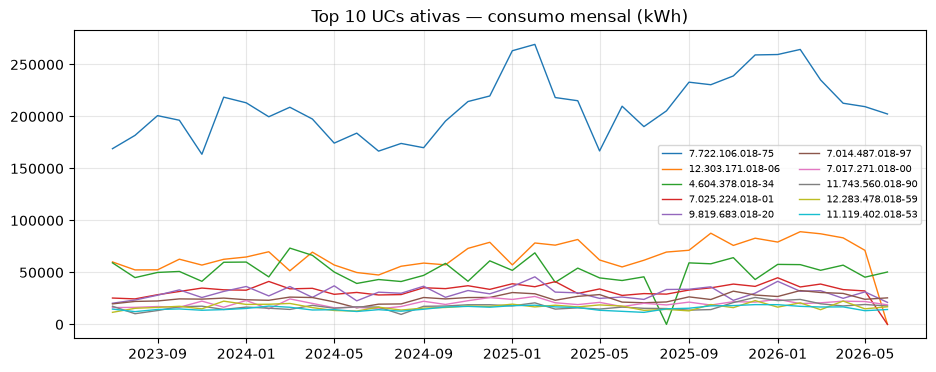

In [10]:
CORTE = pd.Timestamp("2026-05-01")
VALID = pd.Timestamp("2026-06-01")


def serie_uc(uc):
    s = consumo.loc[consumo["uc"] == uc].set_index("mes")["consumo_modelagem"].asfreq("MS")
    return s.interpolate(limit_direction="both")


fig, ax = plt.subplots()
for u in top10:
    ax.plot(serie_uc(u), label=u, lw=1)
ax.set_title("Top 10 UCs ativas — consumo mensal (kWh)")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
plt.show()

Duas coisas saltam do gráfico: as séries têm sazonalidade anual razoável, e duas UCs
grandes (`12.303.171.018-06` e `7.025.224.018-01`) **caem a zero exatamente em
jun/2026**, depois de anos consumindo 70 mil e 30 mil kWh/mês. Isso não é churn com
essa cara — é fatura que não entrou na base. Mantive o zero na validação (é o valor
faturado), mas ele contamina as métricas, e volto nisso adiante.

Modelos: dois baselines (ingênuo = repete o último mês; sazonal ingênuo = repete o
mesmo mês do ano anterior) e um modelo mais avançado (Holt-Winters aditivo com
tendência amortecida — as séries têm nível + sazonalidade, e HW é o mínimo que captura
os dois sem exigir tuning).

In [11]:
def prever(treino, modelo):
    if modelo == "ingênuo":
        return float(treino.iloc[-1])
    if modelo == "sazonal ingênuo":
        return float(treino.iloc[-12])
    if modelo == "holt-winters":
        m = ExponentialSmoothing(treino, trend="add", seasonal="add",
                                 seasonal_periods=12, damped_trend=True).fit()
        return float(m.forecast(1).iloc[0])


MODELOS = ["ingênuo", "sazonal ingênuo", "holt-winters"]
linhas = []
for u in top10:
    s = serie_uc(u)
    treino, real = s[s.index <= CORTE], s.loc[VALID]
    linha = {"uc": u, "real": real}
    for mo in MODELOS:
        linha[mo] = prever(treino, mo)
    linhas.append(linha)
val = pd.DataFrame(linhas)
val.round(0)

,uc,real,ingênuo,sazonal ingênuo,holt-winters
0,7.722.106.018-75,202385.0,209454.0,209859.0,224349.0
1,12.303.171.018-06,0.0,71228.0,55278.0,66715.0
2,4.604.378.018-34,50384.0,45395.0,42208.0,36979.0
3,7.025.224.018-01,0.0,32170.0,27871.0,30177.0
4,9.819.683.018-20,21163.0,31274.0,26324.0,24077.0
5,7.014.487.018-97,25520.0,24134.0,21441.0,20381.0
6,7.017.271.018-00,18795.0,21986.0,17118.0,18041.0
7,11.743.560.018-90,17685.0,19142.0,16639.0,19243.0
8,12.283.478.018-59,16934.0,14973.0,17631.0,14947.0
9,11.119.402.018-53,14308.0,13170.0,12559.0,13039.0


In [12]:
met = []
for mo in MODELOS:
    ae = (val[mo] - val["real"]).abs()
    ape = ae / val["real"].replace(0, np.nan)  # MAPE indefinido onde real = 0
    met.append({"modelo": mo, "MAE": ae.mean(), "MAPE %": 100 * ape.mean(),
                "WAPE %": 100 * ae.sum() / val["real"].sum(),
                "UCs sem MAPE": int(ape.isna().sum())})
pd.DataFrame(met).round(2)

,modelo,MAE,MAPE %,WAPE %,UCs sem MAPE
0,ingênuo,13470.0,13.92,36.69,2
1,sazonal ingênuo,11320.8,11.43,30.83,2
2,holt-winters,14588.2,13.10,39.73,2


**O baseline sazonal ingênuo venceu** — MAE e MAPE menores que o Holt-Winters. Por quê:
são só 35 meses de histórico por UC, o consumo tem sazonalidade anual forte e pouca
tendência; o HW precisa estimar nível, tendência e 12 fatores sazonais com esses
mesmos 35 pontos, e o que ele ganha de flexibilidade perde de variância. Com 2 ciclos
anuais de dados, "repetir o mesmo mês do ano passado" é difícil de bater.

Sobre as métricas: o MAPE ficou **indefinido em 2 das 10 UCs** (real = 0) — nas
demais ainda é utilizável, mas em produção eu usaria WAPE, que não explode com zeros
e pondera pelo tamanho da UC.

Previsão de **julho/2026** com o modelo vencedor, retreinado com junho (para o
sazonal ingênuo isso significa usar jul/2025). Para as duas UCs com fatura faltante
mostro os dois cenários:

In [13]:
prev_jul = {u: prever(serie_uc(u), "sazonal ingênuo") for u in top10}
prev_jul = pd.Series(prev_jul, name="previsao_jul_kwh").round(0)
suspeitas = ["12.303.171.018-06", "7.025.224.018-01"]
print(prev_jul.to_string())
print(f"\nSe as 2 UCs zeradas forem churn de verdade (e não fatura faltante), "
      f"tira-se {prev_jul[suspeitas].sum():,.0f} kWh da previsão.")

7.722.106.018-75     190254.0
12.303.171.018-06     61700.0
4.604.378.018-34      45763.0
7.025.224.018-01      29615.0
9.819.683.018-20      24034.0
7.014.487.018-97      20804.0
7.017.271.018-00      20285.0
11.743.560.018-90     15460.0
12.283.478.018-59     13510.0
11.119.402.018-53     11570.0

Se as 2 UCs zeradas forem churn de verdade (e não fatura faltante), tira-se 91,315 kWh da previsão.


### (b) Geração da usina

Olhando o histórico inteiro (gráfico da Q0), a série tem três regimes:
ramp-up até o início de 2024, o colapso de mar–jun/2024, e a partir de **jul/2024 um
patamar novo** (~500–600 mil kWh/mês — a usina claramente ganhou capacidade).

**Decisão de treino: só a partir de jul/2024.** O regime antigo descreve uma usina
que não existe mais, e o colapso é um evento operacional, não um padrão a aprender.
Fica um problema honesto: sobram só 23 meses, menos de 2 ciclos — nem dá pra ajustar
sazonalidade de 12 meses com isso (o statsmodels exige 24 pontos). Então o "avançado"
aqui é um Holt amortecido (nível + tendência), e suavizo o pico isolado de jan/2026
(866 mil, 54% acima dos vizinhos) pela média dos meses ao lado.

In [14]:
ger = usina.set_index("mes")["geracao_kwh"].asfreq("MS").astype(float)
treino_g = ger[(ger.index >= "2024-07-01") & (ger.index <= CORTE)].copy()
real_g = ger.loc[VALID]

treino_g_suave = treino_g.copy()
treino_g_suave.loc["2026-01-01"] = (treino_g.loc["2025-12-01"] + treino_g.loc["2026-02-01"]) / 2

cand = {
    "ingênuo (mai/26)": treino_g.iloc[-1],
    "sazonal ingênuo (jun/25)": ger.loc["2025-06-01"],
    "média 12m": treino_g.tail(12).mean(),
    "holt amortecido": float(ExponentialSmoothing(
        treino_g_suave, trend="add", damped_trend=True).fit().forecast(1).iloc[0]),
}
pd.DataFrame({
    "previsão jun/26": cand,
    "MAE": {k: abs(v - real_g) for k, v in cand.items()},
    "MAPE %": {k: 100 * abs(v - real_g) / real_g for k, v in cand.items()},
}).round(1)

,previsão jun/26,MAE,MAPE %
ingênuo (mai/26),412810.0,13460.0,3.4
sazonal ingênuo (jun/25),500514.0,101164.0,25.3
média 12m,553791.2,154441.2,38.7
holt amortecido,428409.9,29059.9,7.3


**O baseline ingênuo venceu, e não foi pouco** (MAPE 3,4% contra 7,3% do Holt e 25%
do sazonal). O motivo está no gráfico: a geração de 2026 cai mês a mês desde
fevereiro (533 → 501 → 460 → 413 → 399 mil). Numa série em deriva recente, o último
valor carrega mais informação do que qualquer média ou padrão sazonal do ano passado —
e o Holt, com 23 pontos, ainda sofre a influência do período de alta de 2024/25.
O sazonal ingênuo erra feio porque jun/2025 pertence a um "momento" da usina que não
é mais o atual. Baseline venceu; fica dito.

Retreinando com junho, a previsão de **julho/2026** é a do ingênuo = valor de junho:

In [15]:
prev_ger_jul = float(ger.iloc[-1])
print(f"Geração prevista jul/2026: {prev_ger_jul:,.0f} kWh")

Geração prevista jul/2026: 399,350 kWh


> A queda contínua de 2026 (−54% vs o pico de janeiro) merece investigação técnica
> (sujidade, degradação, curtailment?). Volto nisso na Q5, porque muda a conta da
> cobertura nos meses seguintes.

### A usina cobre a carteira em julho/2026?

Preciso do consumo previsto da **carteira inteira**, não só do top 10. Detalhe: o
total de jun/2026 (539 mil) despenca vs mai/2026 (643 mil) — mas ~103 mil disso são
exatamente as duas faturas faltantes. Corrigindo isso, a carteira está estável na
faixa de 640–700 mil kWh/mês. Para julho, uso o mesmo critério vencedor da (a),
sazonal ingênuo no agregado: jul/2025 = 646 mil (a carteira cresceu de 185 para 200
UCs desde então, então é até conservador).

In [16]:
tot = consumo.groupby("mes")["consumo_kwh"].sum()
prev_consumo_jul = float(tot.loc["2025-07-01"])
saldo_ativas = consumo.loc[(consumo["mes"] == VALID) & (~consumo["cancelada"]), "saldo_kwh"].sum()

print(f"consumo previsto jul/26:  {prev_consumo_jul:>10,.0f} kWh")
print(f"geração prevista jul/26:  {prev_ger_jul:>10,.0f} kWh")
print(f"cobertura pela geração:   {100 * prev_ger_jul / prev_consumo_jul:>9.1f} %")
print(f"déficit do mês:           {prev_consumo_jul - prev_ger_jul:>10,.0f} kWh")
print(f"saldo das UCs ativas:     {saldo_ativas:>10,.0f} kWh")

consumo previsto jul/26:     646,218 kWh
geração prevista jul/26:     399,350 kWh
cobertura pela geração:        61.8 %
déficit do mês:              246,868 kWh
saldo das UCs ativas:        166,085 kWh


**Não cobre.** A geração prevista (~399 mil kWh) atende ~62% do consumo previsto
(~646 mil kWh) — déficit de ~247 mil kWh em julho. O saldo acumulado nas UCs ativas
(~166 mil kWh) amortece parte de um mês e acaba.

O que fazer: (1) rodar o rebalanceamento — há ~735 mil kWh de crédito **preso em UCs
canceladas** (Q4), o que banca ~3 meses desse déficit; (2) investigar a queda de
geração de 2026 — se for sujidade/falha, recuperar a usina resolve parte estrutural;
(3) se a queda for permanente, a carteira está overbooked: renegociar quota, captar
geração adicional ou reduzir carteira.

---
## Q4 — Rebalanceamento

**Excedente:** crédito parado em UC que não vai usá-lo. Da Q0: as 10 UCs canceladas
têm consumo zero há meses e saldo parado — esse é o montante a redistribuir.

In [17]:
jun = consumo[consumo["mes"] == VALID].set_index("uc")
excedente = jun.loc[jun["cancelada"], "saldo_kwh"].sum()
jun.loc[jun["cancelada"], ["consumo_kwh", "saldo_kwh"]].sort_values("saldo_kwh", ascending=False)

,consumo_kwh,saldo_kwh
uc,,
3.407.906.018-85,0,218507
8.855.627.018-22,0,126794
7.968.766.018-90,0,122852
8.885.081.018-07,0,65512
9.268.817.018-04,0,59691
8.885.018.018-60,0,43103
3.413.864.018-10,0,32320
288.370.018-72,0,28010
150.728.018-63,0,21544


In [18]:
print(f"excedente a redistribuir: {excedente:,.0f} kWh "
      f"({100 * excedente / jun['saldo_kwh'].sum():.0f}% de todo o saldo da carteira)")

excedente a redistribuir: 734,931 kWh (82% de todo o saldo da carteira)


**Critério de priorização:** o crédito deve ir para quem **certamente vai consumi-lo
logo** — quanto maior e mais estável o consumo da UC, mais rápido o crédito gira e
menor o risco de virar saldo parado de novo (que é o problema que estamos
consertando). Então a alocação é **proporcional ao consumo previsto de julho** (da
Q3: sazonal ingênuo por UC), com a restrição do enunciado: ninguém termina com saldo
acima de **1× o consumo médio dos últimos 12 meses**, e quem já está acima não recebe.

A alocação proporcional com teto é iterativa ("waterfill"): distribuo proporcional,
quem bate no teto sai da rodada e o resto é redistribuído entre os demais.

In [19]:
def rebalancear(montante, saldo, previsao, teto):
    """Aloca `montante` proporcional à previsão de consumo, com teto de saldo final.

    saldo, previsao, teto: Series indexadas por UC.
    Retorna (recebido: Series, sobra: float).
    """
    recebido = pd.Series(0.0, index=saldo.index)
    espaco = (teto - saldo).clip(lower=0.0)
    restante = float(montante)
    while restante > 1e-6:
        livre = espaco - recebido
        eleg = livre[(livre > 1e-9) & (previsao > 0)].index
        if len(eleg) == 0:
            break
        peso = previsao.loc[eleg]
        cota = restante * peso / peso.sum()
        dado = np.minimum(cota, livre.loc[eleg])
        recebido.loc[eleg] += dado
        restante -= float(dado.sum())
    return recebido, restante


ult12 = consumo[consumo["mes"] > VALID - pd.DateOffset(months=12)]
media12 = (ult12[~ult12["cancelada"]].groupby("uc")["consumo_modelagem"]
           .mean().fillna(0.0))

ucs_ativas = jun[~jun["cancelada"]].index
saldo_atual = jun.loc[ucs_ativas, "saldo_kwh"].astype(float)
media12 = media12.reindex(ucs_ativas).fillna(0.0)

# previsão de julho por UC: sazonal ingênuo (jul/25); fallback p/ média 12m se a UC é nova
jul25 = (consumo[consumo["mes"] == "2025-07-01"].set_index("uc")["consumo_modelagem"]
         .reindex(ucs_ativas))
previsao_jul_uc = jul25.fillna(media12)

recebido, sobra = rebalancear(excedente, saldo_atual, previsao_jul_uc, teto=media12)

resultado = pd.DataFrame({
    "consumo_medio_12m": media12.round(0),
    "previsao_jul": previsao_jul_uc.round(0),
    "saldo_antes": saldo_atual,
    "recebido": recebido.round(0),
    "saldo_depois": (saldo_atual + recebido).round(0),
})
resultado = resultado.sort_values("recebido", ascending=False)
resultado.head(15)

,consumo_medio_12m,previsao_jul,saldo_antes,recebido,saldo_depois
uc,,,,,
7.722.106.018-75,228427.0,190254.0,0.0,228427.0,228427.0
12.303.171.018-06,71593.0,61700.0,0.0,71593.0,71593.0
4.604.378.018-34,49216.0,45763.0,0.0,49216.0,49216.0
7.025.224.018-01,32295.0,29615.0,0.0,32295.0,32295.0
9.819.683.018-20,30324.0,24034.0,0.0,30324.0,30324.0
7.014.487.018-97,26875.0,20804.0,0.0,26875.0,26875.0
7.017.271.018-00,20858.0,20285.0,0.0,20858.0,20858.0
11.743.560.018-90,18904.0,15460.0,0.0,18904.0,18904.0
12.283.478.018-59,17071.0,13510.0,0.0,17071.0,17071.0


In [20]:
# quem já estava acima do teto não recebeu nada; quem recebeu não pode ter estourado
ja_acima = saldo_atual > media12
assert (recebido[ja_acima] == 0).all(), "UC acima do teto recebeu crédito"
estourou = (saldo_atual + recebido > media12 + 1e-6) & (recebido > 0)
assert not estourou.any(), "alguma UC estourou o teto ao receber"
print(f"redistribuído: {recebido.sum():,.0f} kWh entre {(recebido > 0).sum()} UCs")
print(f"sobra que não coube em ninguém: {sobra:,.0f} kWh "
      f"({100 * sobra / excedente:.0f}% do excedente)")

redistribuído: 643,476 kWh entre 160 UCs
sobra que não coube em ninguém: 91,455 kWh (12% do excedente)


**Sobrou crédito?** Sim — a carteira ativa não tem "espaço de saldo" suficiente para
absorver tudo o que estava preso nas canceladas (o teto de 1 mês de consumo médio
limita o total absorvível). O que fazer com a sobra:

1. **Captar novas UCs** — é a resposta estrutural: existe crédito garantido esperando
   consumidor, ou seja, dá para crescer a carteira sem investir em geração.
2. Enquanto isso, manter a sobra como **reserva na usina** para amortecer meses de
   geração fraca (e o déficit de julho previsto na Q3 mostra que ela será usada).
3. Lembrando o prazo regulatório: créditos do SCEE expiram em 5 anos — a sobra não
   pode ficar esquecida; precisa de dono e de meta de consumo.